In [1]:
import os
import cv2
import torch
import random
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
pd_path = "../PD Patients"
nonpd_path = "../Non PD Patients"

def get_subjects(base_path, label):
    return [(s, base_path, label) for s in os.listdir(base_path)]

all_subjects = get_subjects(pd_path, 1) + get_subjects(nonpd_path, 0)

train_subjects, test_subjects = train_test_split(
    all_subjects, test_size=0.2, random_state=42
)

In [3]:
class ParkinsonDataset(Dataset):
    def __init__(self, subject_list, max_samples_per_subject=40):
        self.samples = []

        for subject, base_path, label in subject_list:
            path = os.path.join(base_path, subject)

            mri_path = os.path.join(path, "1.MRI")
            dat_path = os.path.join(path, "0.DAT")

            if not os.path.exists(mri_path) or not os.path.exists(dat_path):
                continue

            # MRI files
            mri_files = sorted(os.listdir(mri_path))
            mri_files = [os.path.join(mri_path, f) for f in mri_files]

            if len(mri_files) < 3:
                continue

            # Reduce size
            mri_files = mri_files[::10]

            # Triplets
            triplets = []
            for i in range(1, len(mri_files)-1):
                triplets.append([mri_files[i-1], mri_files[i], mri_files[i+1]])

            # DAT images
            dat_images = []
            for folder in os.listdir(dat_path):
                subfolder = os.path.join(dat_path, folder)
                if os.path.isdir(subfolder):
                    for img in os.listdir(subfolder):
                        dat_images.append(os.path.join(subfolder, img))

            if len(dat_images) == 0:
                continue

            # LIMIT samples (critical for safety)
            count = 0
            for triplet in triplets:
                for dat in dat_images:
                    self.samples.append((triplet, dat, label))
                    count += 1
                    if count >= max_samples_per_subject:
                        break
                if count >= max_samples_per_subject:
                    break

        print("Dataset size:", len(self.samples))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        triplet, dat_path, label = self.samples[idx]

        imgs = []

        # MRI (3 images)
        for p in triplet:
            img = cv2.imread(p)
            if img is None:
                img = np.zeros((224,224,3))
            img = cv2.resize(img, (224,224))
            img = torch.tensor(img).permute(2,0,1).float()/255
            imgs.append(img)

        # DAT (1 image)
        dat = cv2.imread(dat_path)
        if dat is None:
            dat = np.zeros((224,224,3))
        dat = cv2.resize(dat, (224,224))
        dat = torch.tensor(dat).permute(2,0,1).float()/255

        imgs.append(dat)

        return torch.stack(imgs), torch.tensor(label).float()

In [4]:
train_dataset = ParkinsonDataset(train_subjects, max_samples_per_subject=40)
test_dataset = ParkinsonDataset(test_subjects, max_samples_per_subject=20)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print("Train:", len(train_dataset), "Test:", len(test_dataset))

Dataset size: 1677
Dataset size: 220
Train: 1677 Test: 220


In [5]:
from torchvision import models

class ParkinsonModel(nn.Module):
    def __init__(self):
        super().__init__()

        base = models.resnet18(pretrained=True)
        self.cnn = nn.Sequential(*list(base.children())[:-1])

        self.gru = nn.GRU(512, 128, batch_first=True)

        self.fc_dat = nn.Linear(512, 128)

        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, 1)

        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        batch = x.size(0)

        # MRI sequence
        mri_feats = []
        for i in range(3):
            f = self.cnn(x[:, i]).view(batch, -1)
            mri_feats.append(f)

        mri_seq = torch.stack(mri_feats, dim=1)

        _, h = self.gru(mri_seq)
        mri_out = h.squeeze(0)

        # DAT
        dat = self.cnn(x[:, 3]).view(batch, -1)
        dat_out = F.relu(self.fc_dat(dat))

        # Combine
        x = torch.cat([mri_out, dat_out], dim=1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

model = ParkinsonModel().to(device)

C:\Users\pardh\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\pardh\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [6]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(5):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images).squeeze()
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 43.6442
Epoch 2, Loss: 11.7808
Epoch 3, Loss: 10.3374
Epoch 4, Loss: 6.0709
Epoch 5, Loss: 1.8640


In [7]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images).squeeze()
        preds = (torch.sigmoid(outputs) > 0.5).float()

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print("Test Accuracy:", correct/total)

Test Accuracy: 0.7363636363636363


In [8]:
torch.save(model.state_dict(), "parkinson_model.pth")

In [34]:
def predict_single_image(model, image_path):
    model.eval()

    img = cv2.imread(image_path)
    img = cv2.resize(img, (224,224))
    img = torch.tensor(img).permute(2,0,1).float()/255

    mri_triplet = torch.stack([img, img, img])
    dat = img

    x = torch.cat([mri_triplet, dat.unsqueeze(0)], dim=0)
    x = x.unsqueeze(0).to(device)

    with torch.no_grad():
        prob = torch.sigmoid(model(x)).item()

    print("PD" if prob > 0.85 else "Healthy", prob)

In [35]:
predict_single_image(model, "./PD/image.jpg")

PD 0.9888179302215576


In [36]:
predict_single_image(model, "./NPD/image2.jpg")

Healthy 0.7419186234474182


In [37]:
predict_single_image(model, "./PD/image3.jpg")

PD 0.9894399046897888


In [38]:
predict_single_image(model, "./NPD/image4.jpg")

Healthy 0.5534639954566956


In [39]:
predict_single_image(model, "./NPD/image5.jpg")

Healthy 0.6001461744308472


In [40]:
predict_single_image(model, "./PD/image6.jpg")

PD 0.9751530885696411


In [41]:
predict_single_image(model, "./PD/image7.jpg")

Healthy 0.816826581954956


In [42]:
predict_single_image(model, "./PD/image8.jpg")

PD 0.9582602381706238


In [43]:
predict_single_image(model, "./NPD/image9.jpg")

PD 0.9991672039031982


In [44]:
predict_single_image(model, "./NPD/image10.jpg")

PD 0.9985508322715759


In [45]:
predict_single_image(model, "./NPD/image11.jpg")

PD 0.891961395740509


In [46]:
predict_single_image(model, "./NPD/image12.png")

Healthy 0.7675163149833679


In [47]:
predict_single_image(model, "./NPD/image13.png")

Healthy 0.7860737442970276


In [48]:
y_true = []
y_probs = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images).squeeze()
        probs = torch.sigmoid(outputs)

        y_true.extend(labels.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

In [49]:
import numpy as np

threshold = 0.85
y_pred = (np.array(y_probs) > threshold).astype(int)

In [50]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[ 13  47]
 [  0 160]]


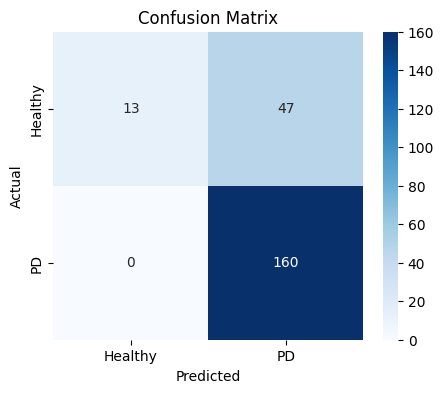

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Healthy","PD"],
            yticklabels=["Healthy","PD"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [52]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

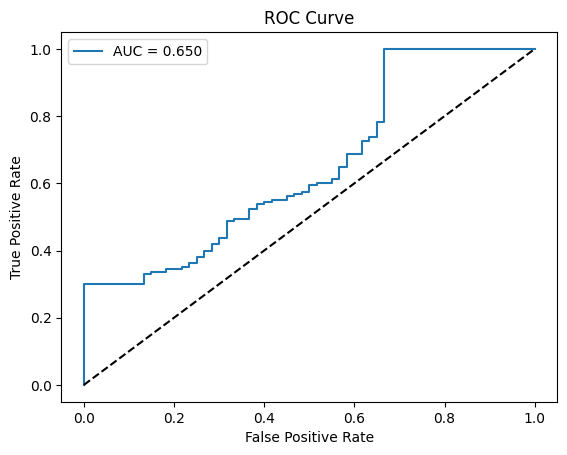

In [53]:
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'k--') 
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [54]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=["Healthy","PD"]))

              precision    recall  f1-score   support

     Healthy       1.00      0.22      0.36        60
          PD       0.77      1.00      0.87       160

    accuracy                           0.79       220
   macro avg       0.89      0.61      0.61       220
weighted avg       0.83      0.79      0.73       220



In [55]:
from sklearn.metrics import f1_score

best_t = 0
best_f1 = 0

for t in np.linspace(0.1, 0.95, 50):
    preds = (np.array(y_probs) > t).astype(int)
    f1 = f1_score(y_true, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best Threshold:", best_t)

Best Threshold: 0.95


In [56]:
def predict_image(model, image_path):
    model.eval()

    img = cv2.imread(image_path)
    img = cv2.resize(img, (224,224))
    img = torch.tensor(img).permute(2,0,1).float()/255

    mri_triplet = torch.stack([img, img, img])
    dat = img

    x = torch.cat([mri_triplet, dat.unsqueeze(0)], dim=0)
    x = x.unsqueeze(0).to(device)

    with torch.no_grad():
        prob = torch.sigmoid(model(x)).item()

    print("PD" if prob > 0.95 else "Healthy", prob)

In [57]:
predict_image(model, "./PD/image.jpg")

PD 0.9888179302215576


In [59]:
predict_image(model, "./NPD/image13.png")

Healthy 0.7860737442970276


In [60]:
predict_image(model, "./NPD/image12.png")

Healthy 0.7675163149833679


In [2]:
class ParkinsonModel(nn.Module):
    def __init__(self):
        super().__init__()

        base = models.resnet18(pretrained=False) 
        self.cnn = nn.Sequential(*list(base.children())[:-1])

        self.gru = nn.GRU(512, 128, batch_first=True)

        self.fc_dat = nn.Linear(512, 128)

        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, 1)

        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        batch = x.size(0)

        # MRI sequence
        mri_feats = []
        for i in range(3):
            f = self.cnn(x[:, i]).view(batch, -1)
            mri_feats.append(f)

        mri_seq = torch.stack(mri_feats, dim=1)

        _, h = self.gru(mri_seq)
        mri_out = h.squeeze(0)

        # DAT
        dat = self.cnn(x[:, 3]).view(batch, -1)
        dat_out = F.relu(self.fc_dat(dat))

        # Combine
        x = torch.cat([mri_out, dat_out], dim=1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
import numpy as np
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
model = ParkinsonModel().to(device)
model.load_state_dict(torch.load("parkinson_model.pth", map_location=device))
model.eval()

print("Model loaded successfully")

C:\Users\pardh\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\pardh\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded successfully


In [4]:
def load_image(path):
    img = cv2.imread(path)

    if img is None:
        raise ValueError(f"Image not found: {path}")

    img = cv2.resize(img, (224, 224))
    img = img / 255.0

    img = torch.tensor(img).permute(2, 0, 1).float()
    return img

In [5]:
def predict_full(mri_paths, dat_path, threshold=0.95):
    model.eval()

    imgs = []

    # MRI (3 images)
    for path in mri_paths:
        imgs.append(load_image(path))

    # DAT (1 image)
    imgs.append(load_image(dat_path))

    x = torch.stack(imgs).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(x)
        prob = torch.sigmoid(output).item()

    if prob > threshold:
        label = "PD"
    elif prob < 0.5:
        label = "Healthy"
    else:
        label = "Uncertain"

    return label, prob

In [6]:
def predict_single_image(image_path, threshold=0.95):
    model.eval()

    img = load_image(image_path)

    # Fake 3 MRI + 1 DAT
    imgs = torch.stack([img, img, img, img]).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(imgs)
        prob = torch.sigmoid(output).item()

    if prob > threshold:
        label = "PD"
    else:
        label = "Healthy"

    return label, prob

In [7]:
label, prob = predict_single_image("../pd_env/PD/image.jpg")

print(label, prob)

PD 0.9888179302215576


In [8]:
label, prob = predict_single_image("../pd_env/NPD/image2.jpg")

print(label, prob)

Healthy 0.7419186234474182


In [9]:
label, prob = predict_single_image("../pd_env/PD/image3.jpg")

print(label, prob)

PD 0.9894399046897888


In [10]:
label, prob = predict_single_image("../pd_env/NPD/image.jpg")

print(label, prob)

Healthy 0.9058113098144531
